# BERT-Tiny News Text Classification

Fine-tune **BERT-tiny** on the **AG News** dataset to classify news articles into World, Sports, Business, and Sci/Tech categories.

In [1]:
# BERT-TINY NEWS TEXT CLASSIFICATION
# Dataset: AG News
#
# Classes:
# World, Sports, Business, Sci/Tech


import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

In [6]:
# 1. LOAD THE DATASET

#
# AG News is a simple news classification dataset.
# Each article belongs to one of four categories.


print("Loading AG News dataset...")

dataset = load_dataset("fancyzhx/ag_news")

print(dataset)




Loading AG News dataset...


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})


In [7]:
# 2. HAVE A QUICK LOOK AT THE DATA

print("\nColumns:")
print(dataset["train"].column_names)

print("\nFirst example:")
print(dataset["train"][0])




Columns:
['text', 'label']

First example:
{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}


In [8]:
# 3. SET THE CLASS NAMES

# The dataset already uses labels from 0 to 3.
# We just give those numbers meaningful names.

label_names = [
    "World",
    "Sports",
    "Business",
    "Sci/Tech"
]

num_labels = len(label_names)

id2label = {
    i: label
    for i, label in enumerate(label_names)
}

label2id = {
    label: i
    for i, label in enumerate(label_names)
}


print("\nNews Categories:")

for i, label in enumerate(label_names):
    print(i, "->", label)



News Categories:
0 -> World
1 -> Sports
2 -> Business
3 -> Sci/Tech


In [9]:
# 4. TAKE A SMALLER SUBSET

#
# The complete AG News dataset is fairly large.
# Using a smaller portion keeps this experiment fast and prevents unnecessary memory usage.

TRAIN_SIZE = 8000
TEST_SIZE = 2000

train_dataset = dataset["train"].shuffle(
    seed=42
).select(
    range(TRAIN_SIZE)
)

test_dataset = dataset["test"].shuffle(
    seed=42
).select(
    range(TEST_SIZE)
)


print("\nDataset sizes:")

print("Training:", len(train_dataset))
print("Testing :", len(test_dataset))





Dataset sizes:
Training: 8000
Testing : 2000


In [10]:
# 5. MAKE A VALIDATION SET

# AG News gives us train and test data.
# We keep 10% of the training data aside for validation.


split_dataset = train_dataset.train_test_split(
    test_size=0.10,
    seed=42
)

train_dataset = split_dataset["train"]

validation_dataset = split_dataset["test"]


print("\nAfter validation split:")

print("Training   :", len(train_dataset))
print("Validation :", len(validation_dataset))
print("Testing    :", len(test_dataset))




After validation split:
Training   : 7200
Validation : 800
Testing    : 2000


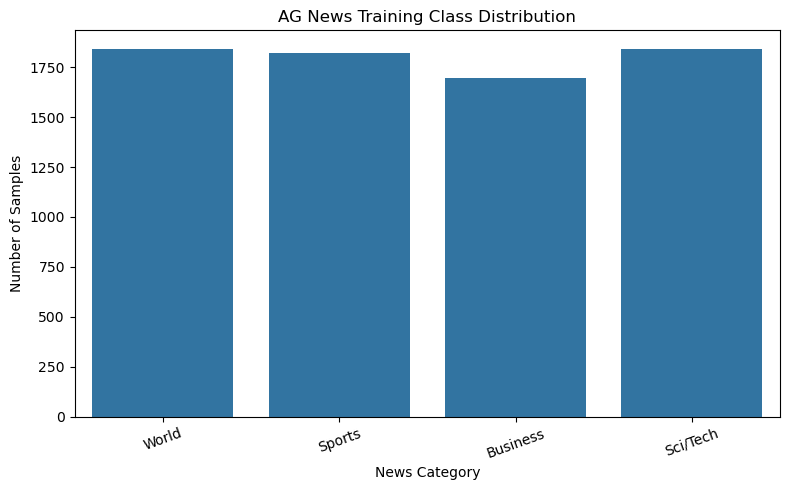

In [11]:
# Quick class distribution visualization
import matplotlib.pyplot as plt
import seaborn as sns

label_counts = np.bincount(train_dataset['label'], minlength=num_labels)
plt.figure(figsize=(8, 5))
sns.barplot(x=label_names, y=label_counts)
plt.xlabel('News Category')
plt.ylabel('Number of Samples')
plt.title('AG News Training Class Distribution')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [13]:
# 6. LOAD BERT-TINY


from transformers import BertTokenizer

MODEL_NAME = "prajjwal1/bert-tiny"

tokenizer = BertTokenizer.from_pretrained(
    MODEL_NAME
)

In [14]:
# 7. TOKENIZE THE NEWS ARTICLES
#
# BERT cannot directly understand raw text.
# The tokenizer converts the articles into token IDs.

def tokenize_function(examples):

    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=128
    )


print("\nTokenizing training data...")

tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"],
    desc="Tokenizing training data"
)


print("Tokenizing validation data...")

tokenized_validation = validation_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"],
    desc="Tokenizing validation data"
)


print("Tokenizing test data...")

tokenized_test = test_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"],
    desc="Tokenizing test data"
)


Tokenizing training data...
Tokenizing validation data...
Tokenizing test data...


In [15]:
# 8. PAD EACH BATCH ONLY AS MUCH AS NEEDED

#
# Instead of making every article exactly 128 tokens long, padding is added dynamically for each batch.

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

In [16]:
# 9. LOAD THE CLASSIFICATION MODEL

from transformers import AutoModelForSequenceClassification

print("\nLoading BERT-tiny model...")

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    revision="refs/pr/16",
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

print("BERT-tiny model loaded successfully!")


Loading BERT-tiny model...


config.json:   0%|          | 0.00/307 [00:00<?, ?B/s]

c:\Users\Shruti\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Shruti\.cache\huggingface\hub\models--prajjwal1--bert-tiny. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
c:\Users\Shruti\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-sys

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 17.8MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/39 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: prajjwal1/bert-tiny
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were 

BERT-tiny model loaded successfully!


In [17]:
# 10. DEFINE THE EVALUATION METRICS


def compute_metrics(pred):

    predictions = np.argmax(
        pred.predictions,
        axis=1
    )

    labels = pred.label_ids

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average="weighted",
            zero_division=0
        )
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }



In [18]:
# 11. TRAINING SETTINGS

training_args = TrainingArguments(

    output_dir="./bert_tiny_agnews_results",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    num_train_epochs=5,

    weight_decay=0.01,

    logging_steps=100,

    load_best_model_at_end=True,

    metric_for_best_model="f1",

    greater_is_better=True,

    save_total_limit=1,

    report_to="none",

    fp16=torch.cuda.is_available(),

    dataloader_pin_memory=False
)




In [20]:
# 12. CREATE THE TRAINER

trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=tokenized_train,

    eval_dataset=tokenized_validation,

    processing_class=tokenizer,

    data_collator=data_collator,

    compute_metrics=compute_metrics
)

In [21]:
# 13. TRAIN THE MODEL

print("\nSTARTING BERT-TINY TRAINING\n")

trainer.train()





STARTING BERT-TINY TRAINING



Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.762519,0.703040,0.833750,0.831841,0.833750,0.832010
2,0.477702,0.477780,0.860000,0.859816,0.860000,0.859304
3,0.383410,0.430072,0.857500,0.857967,0.857500,0.857345
4,0.359960,0.414537,0.863750,0.864524,0.863750,0.863682
5,0.324054,0.415649,0.861250,0.862336,0.861250,0.861218


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=4500, training_loss=0.5435414810180664, metrics={'train_runtime': 477.9388, 'train_samples_per_second': 75.323, 'train_steps_per_second': 9.415, 'total_flos': 7193198023488.0, 'train_loss': 0.5435414810180664, 'epoch': 5.0})

In [22]:
# 14. CHECK PERFORMANCE ON THE TEST SET

print("\nEvaluating model on test data...")

results = trainer.evaluate(
    tokenized_test
)


print("\n")
print("FINAL TEST RESULTS\n")

print(
    f"Accuracy  : {results['eval_accuracy']:.4f}"
)

print(
    f"Precision : {results['eval_precision']:.4f}"
)

print(
    f"Recall    : {results['eval_recall']:.4f}"
)

print(
    f"F1 Score  : {results['eval_f1']:.4f}"
)





Evaluating model on test data...


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.324054,0.398436,5,0.872500,0.873740,0.872500,0.872116




FINAL TEST RESULTS

Accuracy  : 0.8725
Precision : 0.8737
Recall    : 0.8725
F1 Score  : 0.8721


In [23]:
# 15. GET THE MODEL'S PREDICTIONS

predictions = trainer.predict(
    tokenized_test
)

y_pred = np.argmax(
    predictions.predictions,
    axis=1
)

y_true = predictions.label_ids

In [24]:
# 16. DETAILED CLASSIFICATION REPORT

print("\n")
print("CLASSIFICATION REPORT")
print("\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=label_names,
        zero_division=0
    )
)



CLASSIFICATION REPORT


              precision    recall  f1-score   support

       World       0.92      0.86      0.89       497
      Sports       0.94      0.97      0.96       483
    Business       0.84      0.79      0.81       522
    Sci/Tech       0.80      0.88      0.84       498

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000



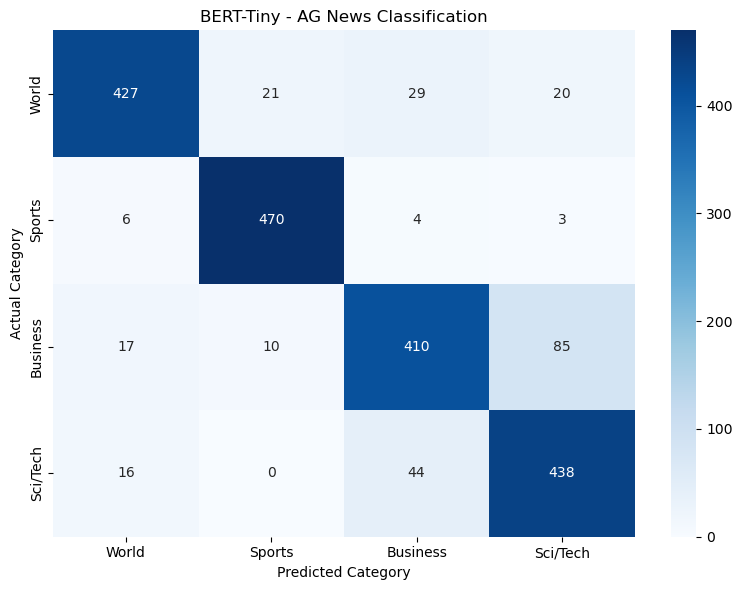

In [25]:
# 17. CONFUSION MATRIX


cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names
)

plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")

plt.title(
    "BERT-Tiny - AG News Classification"
)

plt.tight_layout()

plt.show()

In [26]:
# 18. FUNCTION FOR CLASSIFYING NEW NEWS

def predict_news_category(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    device = next(
        model.parameters()
    ).device

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    model.eval()

    with torch.no_grad():

        outputs = model(**inputs)

    probabilities = torch.softmax(
        outputs.logits,
        dim=1
    )

    predicted_id = torch.argmax(
        probabilities,
        dim=1
    ).item()

    confidence = (
        probabilities[0][predicted_id].item()
        * 100
    )

    predicted_category = id2label[
        predicted_id
    ]

    return predicted_category, confidence




In [27]:
# 19. TRY IT ON A NEW NEWS ARTICLE

sample_text = """
Apple announced a new generation of artificial intelligence
chips designed to improve the performance of its latest
computing devices and machine learning applications.
"""


prediction, confidence = predict_news_category(
    sample_text
)


print("\n")
print("NEWS TEXT CLASSIFIER\n")

print("\nInput:")
print(sample_text)

print("\nPredicted Category:")
print(prediction)

print(
    f"\nConfidence: {confidence:.2f}%\n"
)




NEWS TEXT CLASSIFIER


Input:

Apple announced a new generation of artificial intelligence
chips designed to improve the performance of its latest
computing devices and machine learning applications.


Predicted Category:
Sci/Tech

Confidence: 90.28%

